In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

In [2]:
df = pd.read_csv("ai_resume_screening.csv")

In [3]:
X = df.drop("shortlisted", axis=1)
y = LabelEncoder().fit_transform(df["shortlisted"])

In [4]:
num_cols = [
    "years_experience",
    "skills_match_score",
    "project_count",
    "resume_length",
    "github_activity"
]

cat_cols = ["education_level"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        eval_metric="logloss",
        random_state=42
    )
}

In [7]:
results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    start = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "Training Time": train_time
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Training Time
5,XGBoost,0.906500,0.927697,0.939423,0.933523,0.966991,0.508616
2,SVM,0.906000,0.926039,0.940615,0.933270,0.947645,46.253943
0,Logistic Regression,0.905500,0.928605,0.936799,0.932684,0.964996,0.071542
4,Gradient Boosting,0.904333,0.925065,0.939184,0.932071,0.966783,4.636593
3,Random Forest,0.897833,0.919400,0.935845,0.927550,0.961673,1.384712
1,Naive Bayes,0.878500,0.949403,0.872645,0.909407,0.957045,0.024114


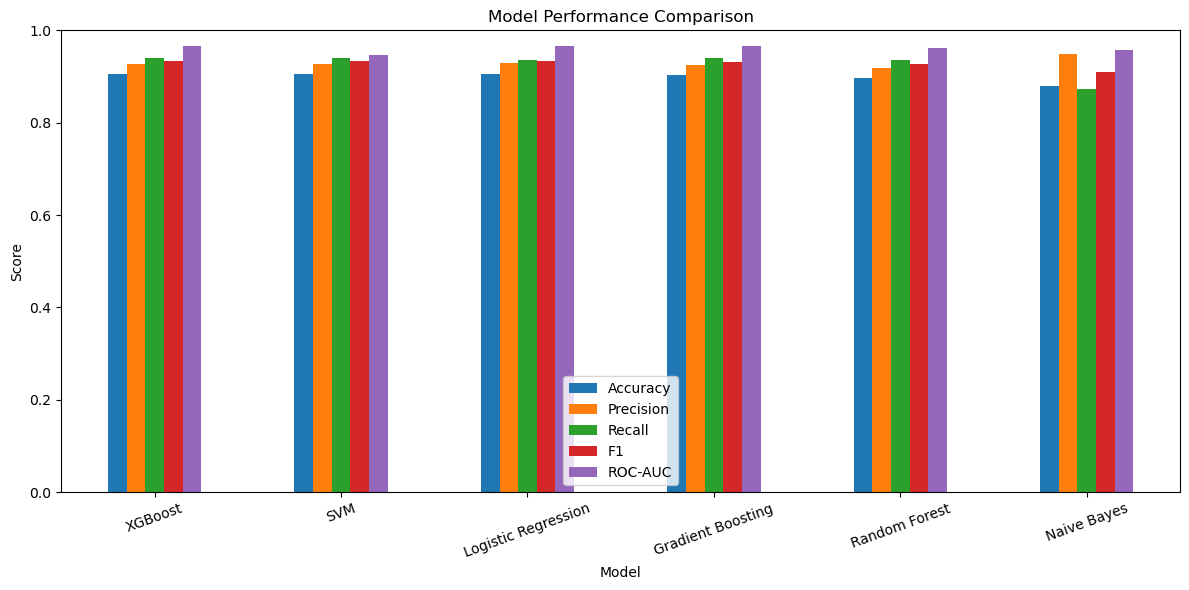

In [8]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

results_df.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [9]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best Model:", best_model_name)

y_pred = best_model.predict(X_test)




Best Model: XGBoost


In [10]:
new_candidate = pd.DataFrame({
    "years_experience": [4],
    "skills_match_score": [83],
    "education_level": ["Masters"],
    "project_count": [7],
    "resume_length": [500],
    "github_activity": [200]
})

best_model.predict(new_candidate)

array([1])

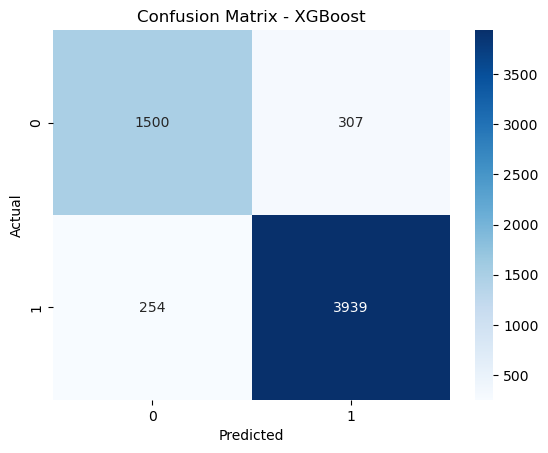

In [11]:
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
